In [ ]:
from gzip import open as gopen
from os.path import expanduser,isfile
from utils import *
from typing import Dict
import os, re, math
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle 
import matplotlib.colors as mcolors
import treeswift

In [2]:
taxon_set_1 = '''SRR32254302|A/cattle/NV/25-002645-005-original/2025|H5N1|USA-NV|2025-01-21|cattle|D1.1
SRR32254303|A/cattle/NV/25-002645-004-original/2025|H5N1|USA-NV|2025-01-21|cattle|D1.1
SRR32254304|A/cattle/NV/25-002645-003-original/2025|H5N1|USA-NV|2025-01-21|cattle|D1.1
SRR32254301|A/cattle/NV/25-002645-006-original/2025|H5N1|USA-NV|2025-01-21|cattle|D1.1
SRR33124777|A/cattle/NV/25-006535-001-original/2025|H5N1|USA-NV|2025-02-17|cattle|D1.1
EPI_ISL_19726293|A/Nevada/10/2025|H5N1|USA-NV|2025-02-04|human|D1.1
EPI_ISL_19829440|A/dairy_cow/Nevada/WD-210/2025|H5N1|USA-NV|2025|cattle|D1.1
SRR32654098|A/cattle/NV/25-003385-001-original/2025|H5N1|USA-NV|2025-01-27|cattle|D1.1
SRR32974123|A/cattle/NV/25-008828-001-original/2025|H5N1|USA-NV|2025-03-09|cattle|D1.1
SRR33124766|A/cattle/NV/25-006538-001-original/2025|H5N1|USA-NV|2025-02-17|cattle|D1.1
SRR33124722|A/cattle/NV/25-006542-003-original/2025|H5N1|USA-NV|2025-02-18|cattle|D1.1
SRR33476830|A/cattle/NV/25-007985-001-original-repeat2/2025|H5N1|USA-NV|2025-03-02|cattle|D1.1
SRR33124733|A/cattle/NV/25-006542-002-original/2025|H5N1|USA-NV|2025-02-18|cattle|D1.1
SRR33124744|A/cattle/NV/25-006542-001-original/2025|H5N1|USA-NV|2025-02-18|cattle|D1.1
SRR33030014|A/cattle/NV/25-006537-001-original-repeat2/2025|H5N1|USA-NV|2025-02-17|cattle|D1.1
SRR32974124|A/cattle/NV/25-008827-001-original/2025|H5N1|USA-NV|2025-03-09|cattle|D1.1
SRR33030013|A/cattle/NV/25-010142-001-original/2025|H5N1|USA-NV|2025-03-16|cattle|D1.1
SRR33476829|A/cattle/NV/25-011565-001-original-repeat2/2025|H5N1|USA-NV|2025-03-30|cattle|D1.1
SRR32654101|A/cattle/United_States/25-003285-006/2025|H5N1|USA|2025|cattle|D1.1
SRR32654099|A/cattle/United_States/25-003285-008/2025|H5N1|USA|2025|cattle|D1.1
SRR32654105|A/cattle/United_States/25-002644-002/2025|H5N1|USA|2025|cattle|D1.1
SRR32654100|A/cattle/United_States/25-003285-007/2025|H5N1|USA|2025|cattle|D1.1
SRR32654106|A/cattle/United_States/25-002644-001/2025|H5N1|USA|2025|cattle|D1.1
SRR32654103|A/cattle/United_States/25-003285-002/2025|H5N1|USA|2025|cattle|D1.1
SRR33030015|A/cattle/United_States/25-002644-003-v/2025|H5N1|USA|2025|cattle|D1.1
SRR33124755|A/cattle/United_States/25-006539-001/2025|H5N1|USA|2025|cattle|D1.1
SRR33124778|A/cattle/United_States/25-006533-001/2025|H5N1|USA|2025|cattle|D1.1'''.strip().split('\n')

taxon_set_2 = '''SRR32512683|A/cattle/AZ/25-004738-001-original/2025|H5N1|USA-AZ|2025-02-06|cattle|D1.1
SRR32512685|A/cattle/AZ/25-004382-001-original/2025|H5N1|USA-AZ|2025-02-03|cattle|D1.1
SRR32415931|A/cattle/AZ/25-004046-001-original/2025|H5N1|USA-AZ|2025-01-31|cattle|D1.1
SRR32512686|A/cattle/AZ/25-004381-001-original/2025|H5N1|USA-AZ|2025-01-31|cattle|D1.1
SRR32415932|A/cattle/AZ/25-004003-002-original/2025|H5N1|USA-AZ|2025-02-03|cattle|D1.1
SRR32415933|A/cattle/AZ/25-004003-001-original/2025|H5N1|USA-AZ|2025-02-03|cattle|D1.1
SRR33124713|A/cattle/AZ/25-006783-001-original/2025|H5N1|USA-AZ|2025-02-21|cattle|D1.1
SRR32804436|A/cattle/AZ/25-007276-003-original/2025|H5N1|USA-AZ|2025-02-21|cattle|D1.1
SRR32804435|A/cattle/AZ/25-007484-010-original/2025|H5N1|USA-AZ|2025-02-26|cattle|D1.1
SRR33476831|A/cattle/AZ/25-007484-009-original-repeat2/2025|H5N1|USA-AZ|2025-02-26|cattle|D1.1
SRR33319085|A/cattle/AZ/25-010942-001-original/2025|H5N1|USA-AZ|2025-03-25|cattle|D1.1
SRR33764593|A/cattle/AZ/25-013772-001-original-repeat2/2025|H5N1|USA-AZ|2025-04-23|cattle|D1.1
SRR33943907|A/cattle/AZ/25-013177-001-original-repeat2/2025|H5N1|USA-AZ|2025-04-17|cattle|D1.1
SRR34709337|A/cattle/AZ/25-019681-001-original/2025|H5N1|USA-AZ|2025-07-02|cattle|D1.1
SRR35150577|A/cattle/United_States/25-021143-001/2025|H5N1|USA|2025|cattle|D1.1
SRR33943908|A/cattle/AZ/25-016334-001-original/2025|H5N1|USA-AZ|2025-05-20|cattle|D1.1
SRR33993166|A/cattle/AZ/25-016765-001-original/2025|H5N1|USA-AZ|2025-05-27|cattle|D1.1'''.strip().split('\n')

taxon_set_1 = ["'" + s + "'" for s in taxon_set_1]
taxon_set_2 = ["'" + s + "'" for s in taxon_set_2]

In [3]:
def codon_to_aa(codon: str) -> str:
    """Convert a codon (3-letter string) to its corresponding amino acid."""
    CODON_TO_AA = {
        'TTT': 'F', 'TTC': 'F', 'TTA': 'L', 'TTG': 'L',
        'TCT': 'S', 'TCC': 'S', 'TCA': 'S', 'TCG': 'S',
        'TAT': 'Y', 'TAC': 'Y', 'TAA': '*', 'TAG': '*',
        'TGT': 'C', 'TGC': 'C', 'TGA': '*', 'TGG': 'W',
        'CTT': 'L', 'CTC': 'L', 'CTA': 'L', 'CTG': 'L',
        'CCT': 'P', 'CCC': 'P', 'CCA': 'P', 'CCG': 'P',
        'CAT': 'H', 'CAC': 'H', 'CAA': 'Q', 'CAG': 'Q',
        'CGT': 'R', 'CGC': 'R', 'CGA': 'R', 'CGG': 'R',
        'ATT': 'I', 'ATC': 'I', 'ATA': 'I', 'ATG': 'M',
        'ACT': 'T', 'ACC': 'T', 'ACA': 'T', 'ACG': 'T',
        'AAT': 'N', 'AAC': 'N', 'AAA': 'K', 'AAG': 'K',
        'AGT': 'S', 'AGC': 'S', 'AGA': 'R', 'AGG': 'R',
        'GTT': 'V', 'GTC': 'V', 'GTA': 'V', 'GTG': 'V',
        'GCT': 'A', 'GCC': 'A', 'GCA': 'A', 'GCG': 'A',
        'GAT': 'D', 'GAC': 'D', 'GAA': 'E', 'GAG': 'E',
        'GGT': 'G', 'GGC': 'G', 'GGA': 'G', 'GGG': 'G'
    }
    return CODON_TO_AA.get(codon, '?')  # '?' for unknown codons


def split_params(s):
    """Split a parameter string on commas outside brackets and quotes."""
    parts = []
    current = []
    i = 0
    in_quotes = False
    stack = []

    open_to_close = {'{': '}', '[': ']', '(': ')'}
    close_to_open = {v: k for k, v in open_to_close.items()}

    while i < len(s):
        c = s[i]

        if c == '"':
            in_quotes = not in_quotes
            current.append(c)
            i += 1
            continue

        if not in_quotes and c in open_to_close:
            stack.append(c)
            current.append(c)
            i += 1
            continue

        if not in_quotes and c in close_to_open:
            if stack and stack[-1] == close_to_open[c]:
                stack.pop()
            else:
                raise ValueError(f"Unmatched closing bracket '{c}' at position {i}")
            current.append(c)
            i += 1
            continue

        if c == ',' and not in_quotes and not stack:
            parts.append(''.join(current).strip())
            current = []
            i += 1
            continue

        current.append(c)
        i += 1

    if current:
        parts.append(''.join(current).strip())

    if stack:
        raise ValueError(f"Unmatched opening bracket(s): {''.join(stack)}")

    return parts


def parse_nested_value(value):
    """Parse nested structures with brackets, numbers, and quoted strings."""
    def try_number(x):
        try:
            return int(x)
        except:
            try:
                return float(x)
            except:
                return x.strip('"').strip("'")

    def tokenize(s):
        tokens = []
        current = []
        stack = []
        i = 0
        in_quotes = False

        while i < len(s):
            c = s[i]

            if c == '"':
                in_quotes = not in_quotes
                current.append(c)
                i += 1
                continue

            if not in_quotes and c in '{[(':
                stack.append(c)
                current.append(c)
                i += 1
                continue

            if not in_quotes and c in '}])':
                if stack and ((stack[-1], c) in [('(', ')'), ('[', ']'), ('{', '}')]):
                    stack.pop()
                current.append(c)
                i += 1
                continue

            if c == ',' and not in_quotes and not stack:
                tokens.append(''.join(current).strip())
                current = []
                i += 1
                continue

            current.append(c)
            i += 1

        if current:
            tokens.append(''.join(current).strip())

        return tokens

    def parse_structure(s):
        s = s.strip()
        if not s:
            return []

        if ((s.startswith('{') and s.endswith('}')) or
            (s.startswith('[') and s.endswith(']')) or
            (s.startswith('(') and s.endswith(')'))):
            inner = s[1:-1].strip()
            tokens = tokenize(inner)
            return [parse_structure(tok) if tok and tok[0] in '{[(' else try_number(tok) for tok in tokens]

        return try_number(s)

    return parse_structure(value)


def read_mcc_tree(tree, params='both'):
    """
    Load a tree (TreeSwift object, path, or Newick string) and parse parameter
    strings into structured dicts attached as `*_params_custom`, while leaving
    the original `*_params` attributes untouched.

    Parameters
    ----------
    tree : treeswift.Tree | str
        TreeSwift tree object, a path to a tree file (.nexus or .newick), or a Newick string.
    params : {'node','edge','both'}
        Which parameter blocks to parse.

    Returns
    -------
    treeswift.Tree
        Same tree with:
          - n.node_params_custom : dict (parsed) or {}
          - n.edge_params_custom : dict (parsed) or {}
        Original n.node_params / n.edge_params are left unmodified.
    """
    if params not in {'node', 'edge', 'both'}:
        raise ValueError("params must be one of {'node','edge','both'}")

    # --- Load tree if a string was passed ---
    if not isinstance(tree, (treeswift.Tree, str)):
        raise ValueError('Tree must be a treeswift.Tree object, a path, or a Newick string')

    if isinstance(tree, str):
        if os.path.exists(tree):
            if tree.lower().endswith('.nexus'):
                tree_d = treeswift.read_tree_nexus(tree)
                for k in ('TREE1', 'tree1', 'TREE', 'tree'):
                    if k in tree_d:
                        tree = tree_d[k]
                        break
                else:
                    raise ValueError("Could not find a tree entry inside the NEXUS file.")
            else:
                tree = treeswift.read_tree_newick(tree)
        else:
            # Treat as raw Newick string
            try:
                tree = treeswift.read_tree_newick(tree)
            except Exception:
                raise ValueError('The tree path does not exist or the Newick string is invalid')

    # copy tree
    tree = tree.extract_subtree(tree.root)

    # --- Helpers ---

    def _split_top_level_pairs(s):
        """Split 'k=v,k=v,...' ignoring commas inside {...} blocks."""
        parts, buf, depth = [], [], 0
        for ch in str(s):
            if ch == '{':
                depth += 1
            elif ch == '}':
                depth = max(0, depth - 1)
            if ch == ',' and depth == 0:
                part = ''.join(buf).strip()
                if part:
                    parts.append(part)
                buf = []
            else:
                buf.append(ch)
        tail = ''.join(buf).strip()
        if tail:
            parts.append(tail)
        return parts

    def _coerce_scalar(value_str):
        """Coerce to int/float/bool/None where possible, else return string."""
        s = value_str.strip()
        low = s.lower()
        if low in {'none', 'null'}:
            return None
        if low in {'true', 'false'}:
            return low == 'true'
        try:
            return int(s)
        except ValueError:
            pass
        try:
            return float(s)
        except ValueError:
            pass
        return s

    def _parse_mutation_blocks(value_str):
        """
        Parse robust-counting blocks like:
          {position,height,from,to}{position,height,from,to}
        Returns a list of dicts or None if no blocks present.
        """
        blocks = re.findall(r'\{([^{}]+)\}', value_str)
        if not blocks:
            return None
        parsed = []
        for block in blocks:
            parts = [p.strip() for p in block.split(',')]
            if len(parts) != 4:
                raise ValueError(f"Malformed mutation block: '{block}'")
            pos_s, height_s, from_s, to_s = parts
            parsed.append({
                "position": int(pos_s),
                "height": float(height_s),
                "from": from_s,
                "to": to_s
            })
        return parsed

    def _parse_params_string(s):
        """
        Parse a params string into a dict.
        - For mutation keys, parse {pos,height,from,to} blocks as dicts.
        - For all other keys, parse {…} as lists of scalars (any length).
        """
        if not isinstance(s, str) or not s.strip():
            return {}

        mutation_keys = {'all_S', 'all_N', 'mutations', 'aa_mutations', 'nuc_mutations', 'substitutionsOfInterest'}

        out = {}
        for pair in _split_top_level_pairs(s):
            m = re.match(r'\s*([^=]+)=(.*)\s*', pair)
            if not m:
                continue
            key, val = m.groups()
            key = key.strip().lstrip('&')
            val = val.strip()

            if '{' in val:
                blocks = re.findall(r'\{([^{}]+)\}', val)
                if key in mutation_keys:
                    parsed_blocks = []
                    for block in blocks:
                        parts = [p.strip() for p in block.split(',')]
                        if len(parts) != 4:
                            raise ValueError(f"Malformed mutation block for key {key}: '{block}'")
                        pos_s, height_s, from_s, to_s = parts
                        parsed_blocks.append({
                            "position": int(pos_s),
                            "height": float(height_s),
                            "from": from_s,
                            "to": to_s
                        })
                    out[key] = parsed_blocks
                else:
                    # generic bracketed value: allow 1-, 2-, 3-tuples etc.
                    parsed = []
                    for block in blocks:
                        parts = [p.strip() for p in block.split(',')]
                        parsed.append([_coerce_scalar(p) for p in parts])
                    # collapse if only one block
                    out[key] = parsed if len(parsed) > 1 else (parsed[0] if len(parsed[0]) > 1 else parsed[0][0])
            else:
                out[key] = _coerce_scalar(val)

        return out


    parse_node = params in {'node', 'both'}
    parse_edge = params in {'edge', 'both'}

    for n in tree.traverse_preorder():
        # NODE: keep n.node_params intact; set n.node_params_custom to parsed dict (or {})
        if parse_node:
            raw_node = getattr(n, 'node_params', None)
            if isinstance(raw_node, str):
                try:
                    n.node_params_custom = _parse_params_string(raw_node)
                except Exception as e:
                    raise ValueError(f"Error parsing node_params for node {n}: {e}")
            else:
                n.node_params_custom = {}

        # EDGE: keep n.edge_params intact; set n.edge_params_custom to parsed dict (or {})
        if parse_edge:
            # if n.is_root():
            #     n.edge_params_custom = {}
            # else:
            raw_edge = getattr(n, 'edge_params', None)
            if isinstance(raw_edge, str):
                try:
                    n.edge_params_custom = _parse_params_string(raw_edge)
                except Exception as e:
                    raise ValueError(f"Error parsing edge_params for node {n}: {e}")
            else:
                n.edge_params_custom = {}

    return tree

In [ ]:
def read_and_operate_beast_trees(nexus_path, func,
                                 apply_translate=True,
                                 burnin_state=0,
                                 test_states=None, 
                                 break_on_first_tree=False,
                                 **func_kwargs):
    """
    Stream over trees in a BEAST .trees/.nexus file and apply `func` to each.

    Args:
        nexus_path (str): Path to a BEAST .trees/.nexus file (.gz OK)
        func: Callable taking a treeswift Tree → returns any value
        apply_translate (bool): Apply TRANSLATE mapping if present
        burnin_state (int): Skip all STATE_X trees where X < burnin_state
        test_states (int|None): If set, only process this many trees (after burn-in)
        break_on_first_tree (bool): If True, return the first tree object instead of applying func
        **kwargs: Additional args for func(tree)

    Returns:
        dict: {tree_name: func(tree)}

    Notes:
        - Only supports BEAST-style one-line-per-tree formats.
        - TRANSLATE is optional; TAXLABELS intentionally unsupported.
    """
    INVALID_NEXUS = "Invalid Nexus file: no trees found"

    if not isinstance(nexus_path, str):
        raise TypeError("nexus_path must be a str")

    path = expanduser(nexus_path)
    lower = path.lower()

    if lower.endswith(".gz"):
        f = gopen(path, "rt")
    elif isfile(path):
        f = open(path)
    else:
        raise FileNotFoundError(f"No such file: {path!r}")

    results = {}
    tr = None
    reading_translate = False

    try:
        for line in f:
            l = line.strip()

            # TRANSLATE block
            if reading_translate:
                if l == ";":
                    reading_translate = False
                else:
                    parts = l.split()
                    if not parts:
                        continue
                    key = parts[0]
                    label = " ".join(parts[1:])
                    if label.endswith(","):
                        label = label[:-1]
                    if tr is None:
                        tr = {}
                    tr[key] = label
                continue

            if l.lower() == "translate":
                tr = {}
                reading_translate = True
                continue

            # TREE line (BEAST-style)
            if l.lower().startswith("tree "):
                first_paren = l.index("(")
                eq_index = l.rindex("=", 0, first_paren)
                left = l[:eq_index].strip()
                right = l[eq_index + 1 :].strip()

                if right.endswith(";"):
                    right = right[:-1].strip()

                if "[" in left:
                    name = " ".join(left.split("[")[0].split()[1:]).strip()
                else:
                    name = " ".join(left.split()[1:])

                # --- NEW: burn-in skip ---
                # Skip STATE_x trees where x < burnin_state
                if name.startswith("STATE_"):
                    try:
                        state_num = int(name.split("_")[1])
                        if state_num <= burnin_state:
                            continue
                    except ValueError:
                        pass  # if format weird, just don't skip

                curr_tree = treeswift.read_tree_newick(right)

                # apply translation if requested
                if apply_translate and tr:
                    for node in curr_tree.traverse_preorder():
                        if node.label is None:
                            continue
                        key = str(node.label)
                        if key in tr:
                            node.id = key
                            node.label = tr[key]
                if break_on_first_tree:
                    print(f"Breaking on first tree: {name}")
                    return curr_tree
                
                results[name] = func(curr_tree, **func_kwargs)
                
                if test_states is not None:
                    if len(results) >= test_states:
                        break

    finally:
        if hasattr(f, "close"):
            f.close()

    if len(results) == 0:
        raise ValueError(INVALID_NEXUS)

    return results


def extract_rc_values(tree: treeswift.Tree, include_root=True) -> Dict[str, float]:
    '''Extract the RC values from a BEAST tree

    Args:
        ``tree`` (``treeswift.Tree``): A BEAST tree with RC values on branches
    Returns:
        ``dict``: A dictionary where keys are RC parameter names and values are the corresponding RC values from the tree
    '''
    tree = read_mcc_tree(tree)
    
    rc_values = {}
    for n in tree.traverse_preorder():
        if n.is_root() and not include_root:
            continue
        if n.edge_params_custom:
            for k, v in n.edge_params_custom.items():
                if k == 'rate':
                    continue
                if k not in rc_values:
                    rc_values[k] = 0
                rc_values[k] += v
    return rc_values


def extract_d11_rc_values(tree: treeswift.Tree, taxon_sets) -> Dict[str, float]:
    '''Extract the D1.1 RC values from a BEAST tree and divide into background and outbreak taxon sets

    Args:
        ``tree`` (``treeswift.Tree``): A BEAST tree with RC values on branches
        ``taxon_sets`` (list of list of str): List of taxon sets to separate RC values into
    Returns:
        ``dict``: A dictionary where keys are RC parameter names and values are the corresponding RC values for the background, outbreak taxon sets, and branches leading to the MRCA of each taxon set
    '''    
    taxon_sets_mrcas = []
    for taxon_set in taxon_sets:
        mrca = tree.mrca(labels=taxon_set)
        taxon_sets_mrcas.append(mrca)
        
    rc_values = {}
    rc_values['whole_tree'] = extract_rc_values(tree)
    rc_values['whole_tree']['treeLength'] = tree.edge_length_sum(terminal=True, internal=True)
    for i, taxon_set in enumerate(taxon_sets):
        set_name = f'set_{i+1}'
        mrca = taxon_sets_mrcas[i]
        
        # RC values for branches within the taxon set
        subtree = tree.extract_subtree(mrca)
        rc_values[f'{set_name}_with_stem'] = extract_rc_values(subtree, include_root=True) # the mrca edge is included here
        rc_values[f'{set_name}_with_stem']['treeLength'] = subtree.edge_length_sum(terminal=True, internal=True)
        rc_values[set_name] = extract_rc_values(subtree, include_root=False)
        rc_values[set_name]['treeLength'] = subtree.edge_length_sum(terminal=True, internal=True) - mrca.get_edge_length()
        
        rc_values[f'set_{i+1}_stem_only'] = {}
        for k, v in rc_values[f'{set_name}_with_stem'].items():
            rc_values[f'set_{i+1}_stem_only'][k] = v - rc_values[set_name].get(k, 0)
            
    rc_values['all_sets_with_stem'] = {}
    for i, taxon_set in enumerate(taxon_sets):
        set_name = f'set_{i+1}_with_stem'
        for k, v in rc_values[set_name].items():
            if k not in rc_values['all_sets_with_stem']:
                rc_values['all_sets_with_stem'][k] = 0
            rc_values['all_sets_with_stem'][k] += v
            
    rc_values['all_sets'] = {}
    for i, taxon_set in enumerate(taxon_sets):
        set_name = f'set_{i+1}'
        for k, v in rc_values[set_name].items():
            if k not in rc_values['all_sets']:
                rc_values['all_sets'][k] = 0
            rc_values['all_sets'][k] += v
            
    rc_values['all_sets_stems_only'] = {}
    for i, taxon_set in enumerate(taxon_sets):
        stem_name = f'set_{i+1}_stem_only'
        for k, v in rc_values[stem_name].items():
            if k not in rc_values['all_sets_stems_only']:
                rc_values['all_sets_stems_only'][k] = 0
            rc_values['all_sets_stems_only'][k] += v
        
    rc_values['background'] = rc_values['whole_tree'].copy()
    for i, taxon_set in enumerate(taxon_sets):
        set_name = f'set_{i+1}_with_stem'
        for k, v in rc_values[set_name].items():
            rc_values['background'][k] -= v
            
    # check if whole_tree values is the sum of background, taxon sets without stem, and the stems
    for k in rc_values['whole_tree'].keys():
        total = rc_values['background'].get(k, 0)
        for i, taxon_set in enumerate(taxon_sets):
            set_name = f'set_{i+1}'
            stem_name = f'set_{i+1}_stem_only'
            total += rc_values[set_name].get(k, 0) + rc_values[stem_name].get(k, 0)
        assert math.isclose(total, rc_values['whole_tree'][k], rel_tol=1e-9), f"RC value mismatch for key {k}: whole_tree={rc_values['whole_tree'][k]}, sum={total}"
            
    return rc_values


trees_path = '../analysis/d11/beast/sep19/RC_empirical/results/D1.1_SEP19.UCLD.trees'
results = read_and_operate_beast_trees(trees_path, extract_d11_rc_values, burnin_state=1000000, taxon_sets=[taxon_set_1, taxon_set_2])

,region,segment,mean,median,std,count,hpd95_low,hpd95_high,hpd80_low,hpd80_high,hpd50_low,hpd50_high
0,all_sets,total,0.299,0.294,0.061,485,0.191,0.423,0.220,0.366,0.241,0.315
1,all_sets_stems_only,total,0.404,0.386,0.166,485,0.138,0.752,0.186,0.568,0.257,0.450
2,all_sets_with_stem,total,0.323,0.319,0.056,485,0.219,0.434,0.256,0.396,0.286,0.353
3,background,total,0.250,0.250,0.008,485,0.236,0.267,0.240,0.259,0.246,0.256


/var/folders/ls/3swb_7515hv8jb0mjxshss480000gp/T/ipykernel_60509/3370076965.py:187: DeprecationWarning: tol_cset is soft-deprecated since 2.0, please use tol_colors.colorsets instead
  cset = tc.tol_cset('muted')


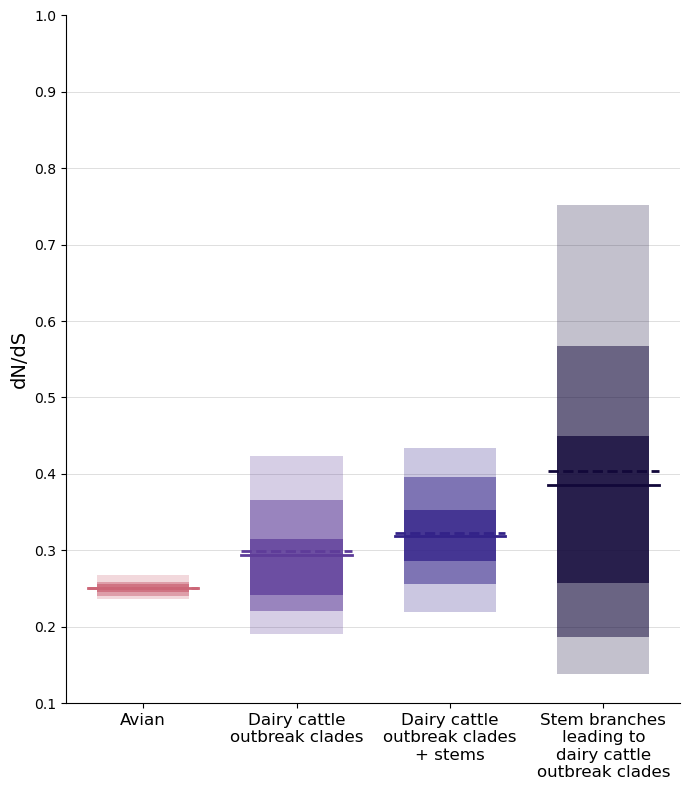

In [ ]:
# convert results to dataframe
all_data = []
for tree_name, rc_dict in results.items():
    for region, rc_values in rc_dict.items():
        row = {'tree': tree_name, 'region': region}
        row.update(rc_values)
        all_data.append(row)
        
df = pd.DataFrame(all_data)
df = df.loc[df['region'].isin(['background', 'all_sets', 'all_sets_with_stem', 'all_sets_stems_only']), :]
df['total.S'] = df.filter(like='.S').sum(axis=1)
df['total.N'] = df.filter(like='.N').sum(axis=1)
df['total.b_u_S'] = df.filter(like='.b_u_S').sum(axis=1)
df['total.b_u_N'] = df.filter(like='.b_u_N').sum(axis=1)
segments = ['total']
segment_lengths = {'PB1': 2280,
                   'PB2': 2274,
                   'PA': 2151,
                   'HA': 1704,
                   'NP': 1497,
                   'NA': 1410,
                   'MP': 936,
                   'NS': 645,
}
segment_lengths['total'] = sum(segment_lengths.values())  


for segment in segments:
    df[f'{segment}_dN/dS'] = (df[f'{segment}.N'] / df[f'{segment}.b_u_N']) / (df[f'{segment}.S'] / df[f'{segment}.b_u_S'])
    df[f'{segment}_rate'] = (df[f'{segment}.N'] + df[f'{segment}.S']) / df['treeLength'] / (segment_lengths[segment] / 3)

# --- melt as before ---
melted = df.melt(
    id_vars=['tree', 'region'],
    value_vars=[f'{segment}_dN/dS' for segment in segments],
    var_name='segment',
    value_name='dN/dS'
)
melted['segment'] = melted['segment'].str.replace('_dN/dS', '')

# ------------------------------------------------------------------
# 1. Compute HPD intervals per region × segment
# ------------------------------------------------------------------

def hpd_single(data, alpha=0.05):
    """Compute HPD interval (mass = 1 - alpha)."""
    data = np.sort(data)
    n = len(data)
    if n == 0:
        return (np.nan, np.nan)
    k = int(np.floor((1 - alpha) * n))
    if k < 1:
        return (data.min(), data.max())
    widths = data[k:] - data[:n - k]
    i = np.argmin(widths)
    return (data[i], data[i + k])

# 95% HPD (mass = 0.95, alpha = 0.05)
hpd_95 = (
    melted.groupby(['region', 'segment'])['dN/dS']
    .apply(lambda x: hpd_single(x, alpha=0.05))
    .reset_index(name='hpd95')
)
hpd_95[['hpd95_low', 'hpd95_high']] = pd.DataFrame(hpd_95['hpd95'].tolist(), index=hpd_95.index)
hpd_95 = hpd_95.drop(columns=['hpd95'])

# 80% HPD (mass = 0.8, alpha = 0.2)
hpd_80 = (
    melted.groupby(['region', 'segment'])['dN/dS']
    .apply(lambda x: hpd_single(x, alpha=0.2))
    .reset_index(name='hpd80')
)
hpd_80[['hpd80_low', 'hpd80_high']] = pd.DataFrame(hpd_80['hpd80'].tolist(), index=hpd_80.index)
hpd_80 = hpd_80.drop(columns=['hpd80'])

# 50% HPD (mass = 0.5, alpha = 0.5)
hpd_50 = (
    melted.groupby(['region', 'segment'])['dN/dS']
    .apply(lambda x: hpd_single(x, alpha=0.5))
    .reset_index(name='hpd50')
)
hpd_50[['hpd50_low', 'hpd50_high']] = pd.DataFrame(hpd_50['hpd50'].tolist(), index=hpd_50.index)
hpd_50 = hpd_50.drop(columns=['hpd50'])

# Merge HPDs into a summary table (for printing and plotting)
summary = (
    melted.groupby(['region', 'segment'])['dN/dS']
    .agg(['mean', 'median', 'std', 'count'])
    .reset_index()
)
summary = summary.merge(hpd_95, on=['region', 'segment'])
summary = summary.merge(hpd_80, on=['region', 'segment'])
summary = summary.merge(hpd_50, on=['region', 'segment'])

# Round for display (optional)
summary['mean'] = summary['mean'].round(3)
summary['median'] = summary['median'].round(3)
summary['std'] = summary['std'].round(3)
summary['count'] = summary['count'].astype(int)
for col in ['hpd95_low', 'hpd95_high', 'hpd80_low', 'hpd80_high', 'hpd50_low', 'hpd50_high']:
    summary[col] = summary[col].round(3)

display(summary)

# ------------------------------------------------------------------
# 2. Limit data to 95% HPD before plotting violins
# ------------------------------------------------------------------

# Merge 95% HPD bounds into melted and filter
melted_95 = melted.merge(hpd_95, on=['region', 'segment'], how='left')
melted_95 = melted_95[
    (melted_95['dN/dS'] >= melted_95['hpd95_low']) &
    (melted_95['dN/dS'] <= melted_95['hpd95_high'])
].copy()

# -------------------------------------------------------
# 3. HPD "boxplots" by region on x, one panel per segment
# -------------------------------------------------------
# sns.set(style="whitegrid", context="talk")

region_order = ['background', 'all_sets', 'all_sets_with_stem', 'all_sets_stems_only']
region_labels = [
    'Avian',
    'Dairy cattle\noutbreak clades',
    'Dairy cattle\noutbreak clades\n+ stems',
    'Stem branches\nleading to\ndairy cattle\noutbreak clades',
]

segment_order = segments  

# Ensure ordering
summary_plot = summary.copy()
summary_plot['segment'] = pd.Categorical(
    summary_plot['segment'],
    categories=segment_order,
    ordered=True
)
summary_plot['region'] = pd.Categorical(
    summary_plot['region'],
    categories=region_order,
    ordered=True
)
summary_plot = summary_plot.sort_values(['segment', 'region'])

# Figure / axes: one column per segment
n_seg = len(segment_order)
fig, axes = plt.subplots(
    1, n_seg,
    # figsize=(4 * n_seg * 1.5, 5),
    figsize=(7, 8),
    sharey=True
)
if n_seg == 1:
    axes = [axes]
    
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['xtick.major.width'] = 0.6
plt.rcParams['ytick.major.width'] = 0.6

# x positions are regions
x_positions = np.arange(len(region_order))

# Color semantics: avian vs outbreak-related
import tol_colors as tc
cset = tc.tol_cset('muted')
avian_color = cset[0]
# outbreak_core = cset[1]
outbreak_core = "#5E3C99"  
outbreak_plus = "#332288"  
outbreak_stem = "#12083A"  



region_to_color = {
    'background': avian_color,
    'all_sets': outbreak_core,
    'all_sets_with_stem': outbreak_plus,
    'all_sets_stems_only': outbreak_stem,
}

def rgba(c, alpha):
    return (*mcolors.to_rgb(c), alpha)

for ax, seg in zip(axes, segment_order):
    for r_idx, region in enumerate(region_order):
        row = summary_plot[
            (summary_plot['segment'] == seg) &
            (summary_plot['region'] == region)
        ]
        if row.empty:
            continue
        row = row.iloc[0]

        color = region_to_color[region]
        x_center = x_positions[r_idx]

        # single box width for all HPDs
        w = 0.6

        # HPD intervals
        y95_low, y95_high = row['hpd95_low'], row['hpd95_high']
        y80_low, y80_high = row['hpd80_low'], row['hpd80_high']
        y50_low, y50_high = row['hpd50_low'], row['hpd50_high']

        if not np.isfinite(
            [y95_low, y95_high, y80_low, y80_high, y50_low, y50_high]
        ).all():
            continue

        # 95% HPD (outer, lightest)
        rect95 = Rectangle(
            (x_center - w / 2, y95_low),
            w,
            y95_high - y95_low,
            facecolor=rgba(color, 0.25),
            edgecolor='none',
            zorder=2,
        )
        ax.add_patch(rect95)
        
        # 80% HPD (middle)
        rect80 = Rectangle(
            (x_center - w / 2, y80_low),
            w,  
            y80_high - y80_low,
            facecolor=rgba(color, 0.5),
            edgecolor='none',
            zorder=3,
        )
        ax.add_patch(rect80)
        
        # 50% HPD (inner, darkest)
        rect50 = Rectangle(
            (x_center - w / 2, y50_low),
            w,
            y50_high - y50_low,
            facecolor=rgba(color, 0.75),
            edgecolor='none',
            zorder=4,
        )
        ax.add_patch(rect50)
        
        # add median line, slightly wider than 50% box
        median = row['median']
        ax.plot(
            [x_center - w / 2 * 1.2, x_center + w / 2 * 1.2],
            [median, median],
            color=rgba(color, 1.0),
            linewidth=2,
            zorder=5,
        )
        
        # add mean line, slighty wider than 50% box, dashed
        mean = row['mean']
        ax.plot(
            [x_center - w / 2 * 1.2, x_center + w / 2 * 1.2],
            [mean, mean],
            color=rgba(color, 1.0),
            linewidth=2,
            linestyle='dashed',
            zorder=5,
        )

    # axis cosmetics per segment
    ax.set_ylim([1e-1, 1.])
    ax.set_yticks([x / 10 for x in range(1, 11)])
    ax.set_yticklabels([str(x / 10) for x in range(1, 11)], fontsize=10)
    ax.set_xlim(-0.5, len(region_order) - 0.5)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(region_labels, rotation=0, ha='center', fontsize=12)

    # light, thin horizontal grid only
    ax.grid(axis='y', color='0.85', linewidth=0.6)
    ax.xaxis.grid(False)

# shared y-label and overall title
axes[0].set_ylabel('dN/dS', fontsize=14)

sns.despine(fig=fig, left=False, bottom=False)

plt.tight_layout()
plt.show()


In [9]:
region_dnds_comparisons = {}
for tree in df['tree'].unique():
    df_tree = df[df['tree'] == tree]
    background_dnds = df_tree[df_tree['region'] == 'background']['total_dN/dS'].values
    all_sets_dnds = df_tree[df_tree['region'] == 'all_sets']['total_dN/dS'].values
    all_sets_with_stem_dnds = df_tree[df_tree['region'] == 'all_sets_with_stem']['total_dN/dS'].values
    all_sets_stems_only_dnds = df_tree[df_tree['region'] == 'all_sets_stems_only']['total_dN/dS'].values
    region_dnds_comparisons[tree] = {
        'all_sets_vs_background': all_sets_dnds[0] - background_dnds[0],
        'all_sets_with_stem_vs_background': all_sets_with_stem_dnds[0] - background_dnds[0],
        'all_sets_stems_only_vs_background': all_sets_stems_only_dnds[0] - background_dnds[0],
        'all_sets_vs_background_log': np.log(all_sets_dnds[0] / background_dnds[0]) if background_dnds[0] > 0 else np.nan,
        'all_sets_with_stem_vs_background_log': np.log(all_sets_with_stem_dnds[0] / background_dnds[0]) if background_dnds[0] > 0 else np.nan,
        'all_sets_stems_only_vs_background_log': np.log(all_sets_stems_only_dnds[0] / background_dnds[0]) if background_dnds[0] > 0 else np.nan,
    }
region_dnds_comparisons_df = pd.DataFrame.from_dict(region_dnds_comparisons, orient='index')
region_dnds_comparisons_p_vals = region_dnds_comparisons_df.applymap(lambda x: x > 0).sum(axis=0)/len(region_dnds_comparisons_df)

region_dnds_comparisons_log_df = pd.DataFrame.from_dict(region_dnds_comparisons, orient='index')[['all_sets_vs_background_log', 'all_sets_with_stem_vs_background_log', 'all_sets_stems_only_vs_background_log']]
for col in region_dnds_comparisons_log_df.columns:
    median = region_dnds_comparisons_log_df[col].median()
    hpd_low, hpd_high = hpd_single(region_dnds_comparisons_log_df[col], alpha=0.05)
    print(col, np.exp(median), np.exp(hpd_low), np.exp(hpd_high))

all_sets_vs_background_log 1.1766511445066399 0.7540469104635837 1.6698720503006672
all_sets_with_stem_vs_background_log 1.2741199917413677 0.9080956885286945 1.80260604790809
all_sets_stems_only_vs_background_log 1.5461186445052064 0.5576713472004358 2.915294721033995


/var/folders/ls/3swb_7515hv8jb0mjxshss480000gp/T/ipykernel_44490/2203454512.py:14: RuntimeWarning: divide by zero encountered in log
  'all_sets_stems_only_vs_background_log': np.log(all_sets_stems_only_dnds[0] / background_dnds[0]) if background_dnds[0] > 0 else np.nan,
/var/folders/ls/3swb_7515hv8jb0mjxshss480000gp/T/ipykernel_44490/2203454512.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  region_dnds_comparisons_p_vals = region_dnds_comparisons_df.applymap(lambda x: x > 0).sum(axis=0)/len(region_dnds_comparisons_df)


In [26]:
region_dnds_comparisons = {}

def get_single(df_tree, region):
    vals = df_tree.loc[df_tree['region'] == region, 'total_dN/dS'].values
    if len(vals) != 1:
        raise ValueError(f"Expected 1 value for region={region}, got {len(vals)}")
    return vals[0]

def safe_log_ratio(num, den):
    if (den > 0) and (num > 0):
        return np.log(num / den)
    else:
        return np.nan

for tree in df['tree'].unique():
    df_tree = df[df['tree'] == tree]

    background = get_single(df_tree, 'background')
    all_sets = get_single(df_tree, 'all_sets')
    all_sets_with_stem = get_single(df_tree, 'all_sets_with_stem')
    stems_only = get_single(df_tree, 'all_sets_stems_only')

    region_dnds_comparisons[tree] = {
        'all_sets_vs_background': all_sets - background,
        'all_sets_with_stem_vs_background': all_sets_with_stem - background,
        'all_sets_stems_only_vs_background': stems_only - background,
        'all_sets_vs_background_log': safe_log_ratio(all_sets, background),
        'all_sets_with_stem_vs_background_log': safe_log_ratio(all_sets_with_stem, background),
        'all_sets_stems_only_vs_background_log': safe_log_ratio(stems_only, background),
    }

region_dnds_comparisons_df = pd.DataFrame.from_dict(region_dnds_comparisons, orient='index')

# Probability group > background (using logs)
log_cols = [
    'all_sets_vs_background_log',
    'all_sets_with_stem_vs_background_log',
    'all_sets_stems_only_vs_background_log',
]
region_dnds_comparisons_log_df = region_dnds_comparisons_df[log_cols]

p_sup = (region_dnds_comparisons_log_df > 0).sum(axis=0) / len(region_dnds_comparisons_log_df)
print(p_sup)

# Median & 95% HPD fold-change
for col in log_cols:
    vals = region_dnds_comparisons_log_df[col].to_numpy()
    vals = vals[np.isfinite(vals)]
    median = np.median(vals)
    
    # 50% HPD interval
    hpd_50_low, hpd_50_high = hpd_single(vals, alpha=0.5)
    hpd_80_low, hpd_80_high = hpd_single(vals, alpha=0.2)
    hpd_95_low, hpd_95_high = hpd_single(vals, alpha=0.05)
    print(f"{col}: \n\tmedian fold-change = {np.exp(median):.3f}, \n\t50% HPD = ({np.exp(hpd_50_low):.3f}, {np.exp(hpd_50_high):.3f}), \n\t80% HPD = ({np.exp(hpd_80_low):.3f}, {np.exp(hpd_80_high):.3f}), \n\t95% HPD = ({np.exp(hpd_95_low):.3f}, {np.exp(hpd_95_high):.3f})")

all_sets_vs_background_log               0.769072
all_sets_with_stem_vs_background_log     0.911340
all_sets_stems_only_vs_background_log    0.822680
dtype: float64
all_sets_vs_background_log: 
	median fold-change = 1.177, 
	50% HPD = (1.038, 1.362), 
	80% HPD = (0.924, 1.535), 
	95% HPD = (0.754, 1.670)
all_sets_with_stem_vs_background_log: 
	median fold-change = 1.274, 
	50% HPD = (1.124, 1.401), 
	80% HPD = (1.023, 1.603), 
	95% HPD = (0.908, 1.803)
all_sets_stems_only_vs_background_log: 
	median fold-change = 1.546, 
	50% HPD = (1.323, 2.224), 
	80% HPD = (0.886, 2.428), 
	95% HPD = (0.560, 2.915)


Figure saved to: ../figures/fig5_dnds_fold_change.pdf


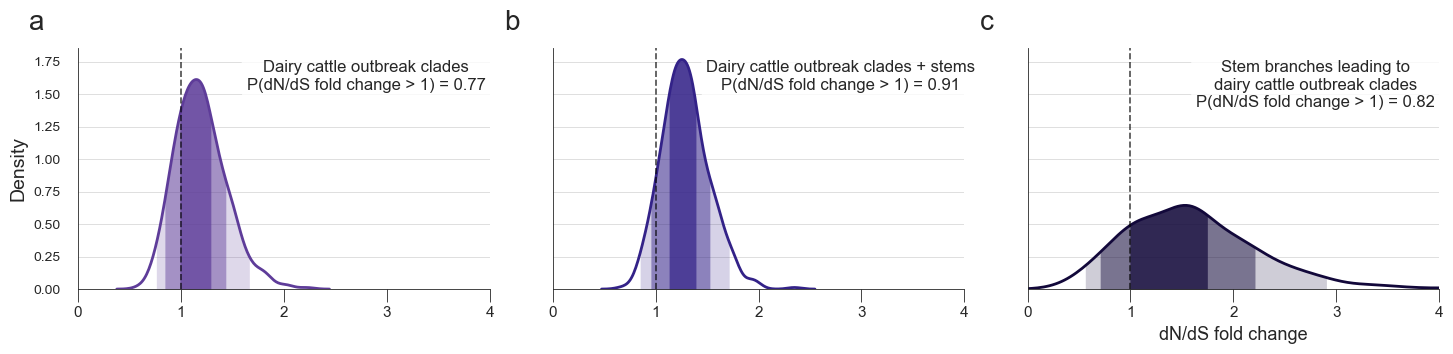

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===== CONFIGURATION =====
FIGURE_SIZE = (15, 3.5)  # Slightly taller for better text visibility
DPI = 300
FOLD_CHANGE_XLIM = (0, 4)
FOLD_CHANGE_XTICKS = np.arange(0, 5, 1)

# Column definitions
COMPARISON_COLS = [
    'all_sets_vs_background_log',
    'all_sets_with_stem_vs_background_log',
    'all_sets_stems_only_vs_background_log',
]

PANEL_LABELS = [
    'Dairy cattle outbreak clades',
    'Dairy cattle outbreak clades + stems',
    'Stem branches leading to\ndairy cattle outbreak clades',
]

# Colors for each comparison
KDE_COLORS = {
    'all_sets_vs_background_log': outbreak_core,
    'all_sets_with_stem_vs_background_log': outbreak_plus,
    'all_sets_stems_only_vs_background_log': outbreak_stem,
}

# HPD interval configurations: (alpha, fill_alpha)
HPD_INTERVALS = [
    (0.05, 0.20),  # 95% HPD
    (0.20, 0.45),  # 80% HPD
    (0.50, 0.70),  # 50% HPD
]

# ===== HELPER FUNCTIONS =====
def _hpd_interval(vals, alpha):
    """
    Compute HPD interval with NaN handling.
    
    Parameters
    ----------
    vals : array-like
        Values to compute HPD for
    alpha : float
        Alpha level (mass = 1 - alpha)
        
    Returns
    -------
    tuple
        (lower, upper) bounds of HPD interval
    """
    vals = np.asarray(vals)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return (np.nan, np.nan)
    return hpd_single(vals, alpha=alpha)


def plot_fold_change_densities(df, cols, labels, kde_colors, figsize=(15, 3)):
    """
    Plot density distributions of dN/dS fold changes with HPD intervals.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing log fold change columns
    cols : list of str
        Column names to plot
    labels : list of str
        Labels for each panel
    kde_colors : dict
        Mapping of column names to colors
    figsize : tuple
        Figure size (width, height)
        
    Returns
    -------
    fig, axes : matplotlib figure and axes
    """
    # Set style
    sns.set(style="white", context="talk")
    plt.rcParams['axes.linewidth'] = 0.6
    plt.rcParams['xtick.major.width'] = 0.6
    plt.rcParams['ytick.major.width'] = 0.6

    # Create subplots WITHOUT sharey - each panel gets its own y-axis
    fig, axes = plt.subplots(1, len(cols), figsize=figsize, sharey=True)
    if len(cols) == 1:
        axes = [axes]

    # Compute posterior probabilities P(fold change > 1)
    prob_greater_than_one = {}
    for col in cols:
        log_vals = df[col].dropna().to_numpy()
        prob_greater_than_one[col] = np.mean(log_vals > 0) if len(log_vals) > 0 else np.nan

    # Plot each comparison
    for index, (ax, col, label) in enumerate(zip(axes, cols, labels)):
        log_vals = df[col].dropna().to_numpy()
        if len(log_vals) < 2:
            continue
            
        fold_changes = np.exp(log_vals)
        color = kde_colors[col]

        # Plot KDE
        sns.kdeplot(x=fold_changes, ax=ax, lw=2, color=color, fill=False)

        # Extract KDE curve for shading
        kde_line = ax.lines[-1]
        x_kde = kde_line.get_xdata()
        y_kde = kde_line.get_ydata()

        # Shade HPD intervals
        for alpha, fill_alpha in HPD_INTERVALS:
            hpd_low, hpd_high = _hpd_interval(fold_changes, alpha=alpha)
            mask = (x_kde >= hpd_low) & (x_kde <= hpd_high)
            if mask.any():
                ax.fill_between(
                    x_kde[mask],
                    0,
                    y_kde[mask],
                    alpha=fill_alpha,
                    color=color,
                    linewidth=0,
                )

        # Reference line at no change (fold change = 1)
        ax.axvline(1.0, linestyle="--", linewidth=1.2, color="black", alpha=0.7)

        # Style axes
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", linewidth=0.6, color="0.85")
        ax.xaxis.grid(False)

        # Set x-axis limits and ticks
        ax.set_xlim(FOLD_CHANGE_XLIM)
        ax.set_xticks(FOLD_CHANGE_XTICKS)
        # Show x-tick labels on ALL panels
        ax.set_xticklabels([str(int(x)) for x in FOLD_CHANGE_XTICKS], fontsize=11)
        ax.tick_params(axis="x", bottom=True, labelbottom=True)

        # Add panel label and probability - positioned at top
        prob = prob_greater_than_one[col]
        if np.isfinite(prob):
            ax.text(
                0.7, 0.95,
                f"{label}\nP(dN/dS fold change > 1) = {prob:.2f}",
                ha="center",
                va="top",
                transform=ax.transAxes,
                fontsize=12,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='none')
            )
        
        if index == 0:
            ax.set_ylabel("Density", fontsize=14)
        else:
            ax.set_ylabel("")
        ax.tick_params(axis='y', labelsize=10)

    # Shared x-axis label
    axes[-1].set_xlabel("dN/dS fold change", fontsize=13)

    plt.tight_layout()
    return fig, axes


# ===== MAIN PLOTTING =====
fig, axes = plot_fold_change_densities(
    region_dnds_comparisons_log_df,
    COMPARISON_COLS,
    PANEL_LABELS,
    KDE_COLORS,
    figsize=FIGURE_SIZE
)

# Add subplot labels (a, b, c)
SUBPLOT_LABELS = ['a', 'b', 'c']
for ax, subplot_label in zip(axes, SUBPLOT_LABELS):
    ax.text(
        -0.1, 1.05,
        subplot_label,
        ha="center",
        va="bottom",
        transform=ax.transAxes,
        fontsize=20,
        fontweight="normal",
    )

# Save figure
output_path = '../figures/fig5_dnds_fold_change.pdf'
fig.savefig(output_path, dpi=DPI, bbox_inches='tight')
print(f"Figure saved to: {output_path}")

plt.show()